<a href="https://colab.research.google.com/github/lisbethmesa-droid/proyecto-marsh-Gestion-proyectos/blob/main/PROYECTO_MARSH_gestion_estrategica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Especialización en Analítica Estratégica de Datos
### **Gestión Estratégica de Proyectos de Analítica**
### **Proyecto Integrador**

---
**Profesor: Camilo Bohorquez**

**Estudiantes:**
- Barrera Gabriela
- Herrera Ivanna
- Mesa Lisbeth

**Institución:** Universidad Pedagógica y Tecnológica de Colombia - UPTC  
**Programa:** Especialización en Analítica Estratégica de Datos  
**Año:** 2026 | Sogamoso, Boyacá

---

**Empresa caso de estudio:** Marsh Colombia  
**Modelos a Implementar:** Regresión Lineal · Regresión Logística  
**Dataset:** Pólizas de seguros - predicción de primas y renovación

---

#**Librerias**

In [1]:
from google.colab import drive
import pandas as pd
from pathlib import Path
import numpy as np
from scipy import stats

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Estadística (sesgo/skewness)
from scipy.stats import skew

# División de datos
from sklearn.model_selection import train_test_split

# Preprocesamiento: imputación, escalado, codificación
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer
from sklearn.compose import ColumnTransformer

# Imputación avanzada (MICE)
from sklearn.experimental import enable_iterative_imputer  # necesario para habilitar IterativeImputer
from sklearn.impute import IterativeImputer

# Pipelines
from sklearn.pipeline import Pipeline

# Selección de variables
from sklearn.feature_selection import SelectKBest, f_regression

# Modelos de regresión (los 2 que se comparan)
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

# Modelo base de referencia (para comparar contra algo ingenuo)
from sklearn.dummy import DummyRegressor

# Métricas de evaluación
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

#**Carga de Datos**

In [2]:
try:
    from google.colab import drive
    drive.mount("/content/drive")
except ImportError:
  print("No estás en Google Colab. Se omite el montaje de Google Drive.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:

rutas_posibles = [
    Path("dataset_polizas_sucio.xlsx"),
    Path("./data/dataset_polizas_sucio.xlsx"),
    Path("/content/dataset_polizas_sucio.xlsx"),
    Path("/content/drive/MyDrive/GESTION_ ESTRATEGICA _PROYECTO_ MARSH_/DATA ORIGINAL/dataset_polizas_sucio.xlsx"),
]

ruta_dataset = next((ruta for ruta in rutas_posibles if ruta.exists()), None)

if ruta_dataset is None:
    raise FileNotFoundError(
        "No se encontró el archivo dataset_polizas_sucio.xlsx. "
        "Verifica la ruta exacta en tu Google Drive."
    )

df = pd.read_excel(ruta_dataset)

print(f"Dataset cargado desde: {ruta_dataset}")
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

Dataset cargado desde: /content/drive/MyDrive/GESTION_ ESTRATEGICA _PROYECTO_ MARSH_/DATA ORIGINAL/dataset_polizas_sucio.xlsx
Filas: 1284
Columnas: 53


In [4]:
df.head()

,id_venta,id_poliza,monto_prima,porcentaje_comision,valor_impuesto,monto_total_venta,fecha_venta,tipo_ramo,fecha_inicio_poliza,fecha_fin_poliza,...,indice_riesgo_combinado,num_tipos_sinistro,es_renovacion,es_cancelada,suma_asegurada_estimada,ramo_alto_riesgo,zona_costera,canal_distribucion,codigo_agente,observaciones
0,VTA0000001,POL000387,1.977802e+08,0.1995,37578244.77,2.353585e+08,2023-12-21,Multirriesgo,NaT,2024-10-11,...,226.525,3,0,0,1977802356,1,1,NaN,NaN,NaN
1,VTA0000002,POL000092,1.717520e+07,0.1629,3263287.33,2.043848e+07,2024-07-01,Manejo,2024-01-14,2025-01-14,...,44.876,2,1,0,171751965,0,0,NaN,NaN,NaN
2,VTA0000005,POL000505,4.917586e+05,0.1793,93434.14,5.851928e+05,2023-04-12,Fianza,2022-12-12,2023-12-12,...,0.715,1,0,0,4917586,0,1,NaN,NaN,NaN
3,VTA0000006,POL000252,1.250678e+06,0.1789,237628.73,1.488306e+06,2024-09-21,Todo Riesgo,2024-04-23,2025-04-23,...,7.890,2,0,0,12506775,1,0,NaN,NaN,NaN
4,VTA0000007,POL000217,3.755291e+06,0.0804,NaN,4.468796e+06,2025-01-27,Automóviles,NaT,2025-01-29,...,11.664,3,0,0,37552910,0,0,NaN,NaN,NaN


# **Clasificacion de Variables**

In [5]:
#Crear diccionario de variables con clasificación
clasificacion = {
    "id_venta": "Identificador",
    "id_poliza": "Identificador",
    "monto_prima": "Cuantitativa continua (Objetivo regresión)",
    "porcentaje_comision": "Cuantitativa continua",
    "valor_impuesto": "Cuantitativa continua",
    "monto_total_venta": "Cuantitativa continua",
    "fecha_venta": "Fecha",
    "tipo_ramo": "Cualitativa nominal",
    "fecha_inicio_poliza": "Fecha",
    "fecha_fin_poliza": "Fecha",
    "codigo_zona_sismica": "Identificador",
    "nivel_riesgo": "Cuantitativa continua",
    "estado_poliza": "Cualitativa nominal",
    "tipo_sector": "Cualitativa nominal",
    "ciudad": "Cualitativa nominal",
    "departamento": "Cualitativa nominal",
    "tamaño_empresa": "Cualitativa ordinal",
    "codigo_divipola": "Identificador",
    "nivel_riesgo_sismico": "Cuantitativa discreta",
    "latitud": "Cuantitativa continua",
    "longitud": "Cuantitativa continua",
    "sector_economico": "Cualitativa nominal",
    "riesgo_sector": "Cuantitativa continua",
    "aseguradora": "Cualitativa nominal",
    "num_sinistros": "Cuantitativa discreta",
    "monto_total_siniestros": "Cuantitativa continua",
    "monto_total_pagado": "Cuantitativa continua",
    "tipos_sinistro": "Cualitativa nominal",
    "sinistros_aprobados": "Cuantitativa discreta",
    "sinistros_rechazados": "Cuantitativa discreta",
    "duracion_poliza_dias": "Cuantitativa discreta",
    "ratio_siniestralidad": "Cuantitativa continua",
    "anio_venta": "Cuantitativa discreta",
    "mes_venta": "Cuantitativa discreta",
    "tiene_sinistro": "Cualitativa binaria (0/1)",
    "log_monto_prima": "Cuantitativa continua",
    "tamaño_empresa_num": "Cualitativa ordinal",
    "antiguedad_meses": "Cuantitativa continua",
    "trimestre_venta": "Cuantitativa discreta",
    "es_temporada_alta": "Cualitativa binaria (0/1)",
    "prima_diaria": "Cuantitativa continua",
    "ratio_aprobacion_sinistros": "Cuantitativa continua",
    "monto_promedio_sinistro": "Cuantitativa continua",
    "indice_riesgo_combinado": "Cuantitativa continua",
    "num_tipos_sinistro": "Cuantitativa discreta",
    "es_renovacion": "Cualitativa binaria (0/1)",
    "es_cancelada": "Cualitativa binaria (0/1) (Objetivo clasificación)",
    "suma_asegurada_estimada": "Cuantitativa continua",
    "ramo_alto_riesgo": "Cualitativa binaria (0/1)",
    "zona_costera": "Cualitativa binaria (0/1)",
    "canal_distribucion": "Cualitativa nominal",
    "codigo_agente": "Identificador",
    "observaciones": "Cualitativa texto libre"
}

# Crear dataframe con clasificación y tipo detectado
diccionario = pd.DataFrame({
    "Clasificación": [clasificacion.get(col, "Por definir") for col in df.columns],
    "Tipo_detectado": df.dtypes.astype(str)
})

# Mostrar tabla completa
pd.set_option('display.max_rows', None)
display(diccionario)

,Clasificación,Tipo_detectado
id_venta,Identificador,object
id_poliza,Identificador,object
monto_prima,Cuantitativa continua (Objetivo regresión),float64
porcentaje_comision,Cuantitativa continua,float64
valor_impuesto,Cuantitativa continua,float64
monto_total_venta,Cuantitativa continua,float64
fecha_venta,Fecha,datetime64[ns]
tipo_ramo,Cualitativa nominal,object
fecha_inicio_poliza,Fecha,datetime64[ns]
fecha_fin_poliza,Fecha,datetime64[ns]


# **Exploracion de Datos**

In [6]:
# 1. Revisar valores nulos
print("Valores nulos por columna:")
print(df.isnull().sum())

Valores nulos por columna:
id_venta                         0
id_poliza                        0
monto_prima                    103
porcentaje_comision            129
valor_impuesto                  90
monto_total_venta                0
fecha_venta                     52
tipo_ramo                       76
fecha_inicio_poliza             65
fecha_fin_poliza                66
codigo_zona_sismica              0
nivel_riesgo                   154
estado_poliza                   89
tipo_sector                      0
ciudad                           0
departamento                     0
tamaño_empresa                 128
codigo_divipola                  0
nivel_riesgo_sismico             0
latitud                        115
longitud                       115
sector_economico               140
riesgo_sector                  142
aseguradora                     64
num_sinistros                    0
monto_total_siniestros         128
monto_total_pagado             128
tipos_sinistro              

In [7]:
#2.Resumen de nulos
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(2)
resumen_nulos = pd.DataFrame({'Nulos': nulos, '% del total': nulos_pct})
resumen_nulos = resumen_nulos[resumen_nulos['Nulos'] > 0].sort_values('Nulos', ascending=False)
print("Columnas con valores nulos:", len(resumen_nulos))
display(resumen_nulos)

Columnas con valores nulos: 25


,Nulos,% del total
observaciones,1284,100.00
canal_distribucion,1284,100.00
codigo_agente,1284,100.00
ratio_siniestralidad,179,13.94
antiguedad_meses,168,13.08
nivel_riesgo,154,11.99
tipos_sinistro,149,11.60
riesgo_sector,142,11.06
sector_economico,140,10.90
porcentaje_comision,129,10.05


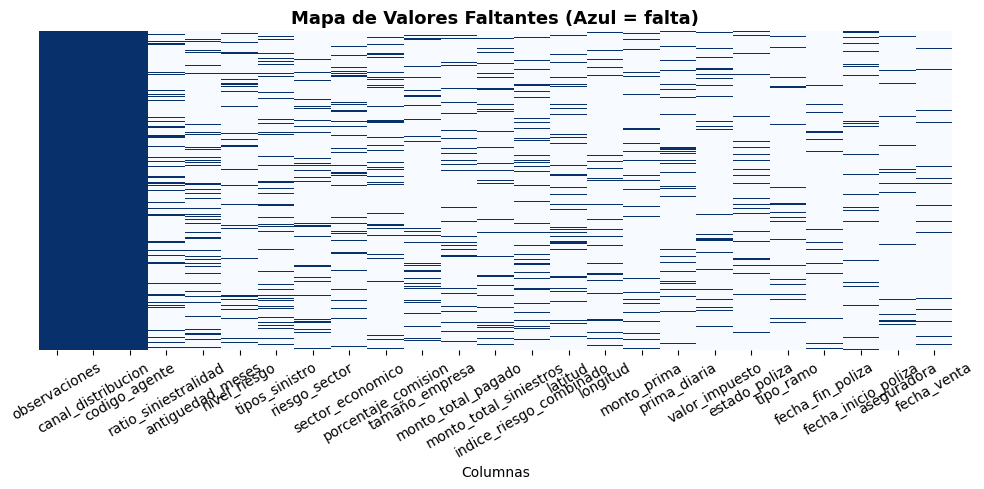

In [8]:
# 3. Mapa visual de nulos
cols_con_nulos = resumen_nulos.index.tolist()
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(df[cols_con_nulos].isnull(), cbar=False, cmap='Blues', yticklabels=False, ax=ax)
ax.set_title('Mapa de Valores Faltantes (Azul = falta)', fontsize=13, fontweight='bold')
ax.set_xlabel('Columnas')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

In [9]:
#4. Valores duplicados
print("Duplicados:", df.duplicated().sum())

Duplicados: 9


In [10]:
#5. espacios en blanco
espacios_df = df.apply(lambda col: col.astype(str).str.strip() == '')
print("Espacios o celdas vacías detectados por columna:")
print(espacios_df.sum())

Espacios o celdas vacías detectados por columna:
id_venta                      0
id_poliza                     0
monto_prima                   0
porcentaje_comision           0
valor_impuesto                0
monto_total_venta             0
fecha_venta                   0
tipo_ramo                     0
fecha_inicio_poliza           0
fecha_fin_poliza              0
codigo_zona_sismica           0
nivel_riesgo                  0
estado_poliza                 0
tipo_sector                   0
ciudad                        0
departamento                  0
tamaño_empresa                0
codigo_divipola               0
nivel_riesgo_sismico          0
latitud                       0
longitud                      0
sector_economico              0
riesgo_sector                 0
aseguradora                   0
num_sinistros                 0
monto_total_siniestros        0
monto_total_pagado            0
tipos_sinistro                0
sinistros_aprobados           0
sinistros_rechazados   

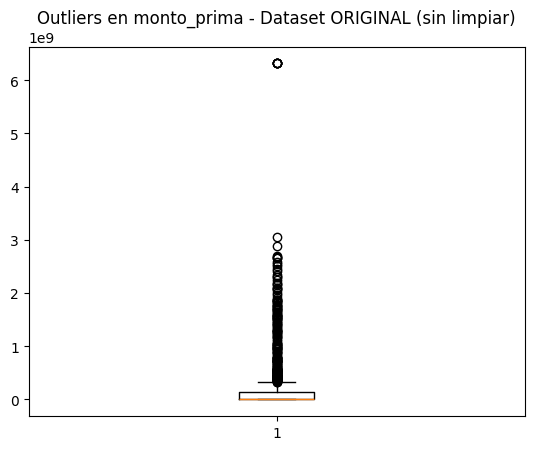

Valores nulos en monto_prima (original): 103
Valor máximo original: 6,314,141,175.00


In [11]:
#6. Visualizar outliers en monto_prima (dataset CRUDO, sin limpiar)
plt.boxplot(df["monto_prima"].dropna())
plt.title("Outliers en monto_prima - Dataset ORIGINAL (sin limpiar)")
plt.show()

print(f"Valores nulos en monto_prima (original): {df['monto_prima'].isnull().sum()}")
print(f"Valor máximo original: {df['monto_prima'].max():,.2f}")

#**Limpieza de Datos**

In [12]:
# Preparación creacion del data limpio
df.columns = df.columns.str.strip()
dfLimpieza = df.copy()

In [13]:
#1 . Eliminar columnas 100% vacías
cols_vacias = dfLimpieza.columns[dfLimpieza.isnull().mean() == 1.0].tolist()
print(f"Columnas eliminadas (100% nulas): {cols_vacias}")
dfLimpieza = dfLimpieza.drop(columns=cols_vacias)

Columnas eliminadas (100% nulas): ['canal_distribucion', 'codigo_agente', 'observaciones']


In [14]:
# 2. Eliminar duplicados
n_dup = dfLimpieza.duplicated().sum()
print(f"Filas duplicadas eliminadas: {n_dup}")
dfLimpieza = dfLimpieza.drop_duplicates().reset_index(drop=True)

Filas duplicadas eliminadas: 9


In [15]:
# 3. Limpiar espacios en texto
cols_texto = dfLimpieza.select_dtypes(include='object').columns
for col in cols_texto:
    dfLimpieza[col] = dfLimpieza[col].str.strip()

if 'ciudad' in dfLimpieza.columns:
    dfLimpieza['ciudad'] = dfLimpieza['ciudad'].str.title()

print(f"Espacios eliminados en {len(cols_texto)} columnas de texto: {list(cols_texto)}")

Espacios eliminados en 11 columnas de texto: ['id_venta', 'id_poliza', 'tipo_ramo', 'estado_poliza', 'tipo_sector', 'ciudad', 'departamento', 'tamaño_empresa', 'sector_economico', 'aseguradora', 'tipos_sinistro']


In [16]:
# 4. Tratamiento de nulos "no aplica" (estructurales)
if 'tipos_sinistro' in dfLimpieza.columns and 'num_sinistros' in dfLimpieza.columns:
    mask_sin_siniestro = dfLimpieza['num_sinistros'] == 0
    dfLimpieza.loc[mask_sin_siniestro, 'tipos_sinistro'] = dfLimpieza.loc[mask_sin_siniestro, 'tipos_sinistro'].fillna('Sin siniestro')
    dfLimpieza['tipos_sinistro'] = dfLimpieza['tipos_sinistro'].fillna('No registrado')
    print(f"'tipos_sinistro' tratado: {mask_sin_siniestro.sum()} marcados como 'Sin siniestro'")
else:
    print("Columnas 'tipos_sinistro' o 'num_sinistros' no encontradas — se omite este paso")

'tipos_sinistro' tratado: 50 marcados como 'Sin siniestro'


#**Imputaciones**

In [17]:
# 5. Imputar categóricas con moda
cols_categoricas_imputar = ['tipo_ramo', 'estado_poliza', 'sector_economico', 'tamaño_empresa', 'aseguradora']
for col in cols_categoricas_imputar:
    if col in dfLimpieza.columns:
        n_nulos_antes = dfLimpieza[col].isnull().sum()
        moda = dfLimpieza[col].mode()[0]
        dfLimpieza[col] = dfLimpieza[col].fillna(moda)
        print(f"{col}: {n_nulos_antes} nulos imputados con moda '{moda}'")

tipo_ramo: 76 nulos imputados con moda 'Automóviles'
estado_poliza: 89 nulos imputados con moda 'Vigente'
sector_economico: 140 nulos imputados con moda 'Suministro de electricidad, gas, vapor y aire acondicionado'
tamaño_empresa: 127 nulos imputados con moda 'Pequeña'
aseguradora: 64 nulos imputados con moda 'HDI'


In [19]:
# 6. Imputar numéricas con mediana
cols_num_mediana = [
    'monto_prima', 'porcentaje_comision', 'valor_impuesto',
    'nivel_riesgo', 'latitud', 'longitud', 'riesgo_sector',
    'ratio_siniestralidad', 'monto_total_siniestros', 'monto_total_pagado',
    'antiguedad_meses', 'indice_riesgo_combinado', 'prima_diaria'
]
for col in cols_num_mediana:
    if col in dfLimpieza.columns:
        n_nulos_antes = dfLimpieza[col].isnull().sum()
        mediana = dfLimpieza[col].median()
        dfLimpieza[col] = dfLimpieza[col].fillna(mediana)
        print(f"{col}: {n_nulos_antes} nulos imputados con mediana {mediana:.2f}")

monto_prima: 102 nulos imputados con mediana 13034790.04
porcentaje_comision: 127 nulos imputados con mediana 0.15
valor_impuesto: 89 nulos imputados con mediana 2404055.40
nivel_riesgo: 153 nulos imputados con mediana 8.38
latitud: 115 nulos imputados con mediana 5.07
longitud: 115 nulos imputados con mediana -75.45
riesgo_sector: 141 nulos imputados con mediana 1.30
ratio_siniestralidad: 178 nulos imputados con mediana 7.42
monto_total_siniestros: 127 nulos imputados con mediana 140456239.90
monto_total_pagado: 127 nulos imputados con mediana 73952547.06
antiguedad_meses: 166 nulos imputados con mediana 24.30
indice_riesgo_combinado: 115 nulos imputados con mediana 31.55
prima_diaria: 102 nulos imputados con mediana 36571.86


In [20]:
#7. Imputar fechas
cols_fecha = ['fecha_venta', 'fecha_inicio_poliza', 'fecha_fin_poliza']
for col in cols_fecha:
    if col in dfLimpieza.columns:
        dfLimpieza[col] = pd.to_datetime(dfLimpieza[col], errors='coerce')
        n_nulos_antes = dfLimpieza[col].isnull().sum()
        dfLimpieza[col] = dfLimpieza[col].fillna(dfLimpieza[col].median())
        print(f"{col}: {n_nulos_antes} nulos imputados con fecha mediana")

fecha_venta: 51 nulos imputados con fecha mediana
fecha_inicio_poliza: 64 nulos imputados con fecha mediana
fecha_fin_poliza: 64 nulos imputados con fecha mediana


#**Deteccion y Tratamiento de Outlers**

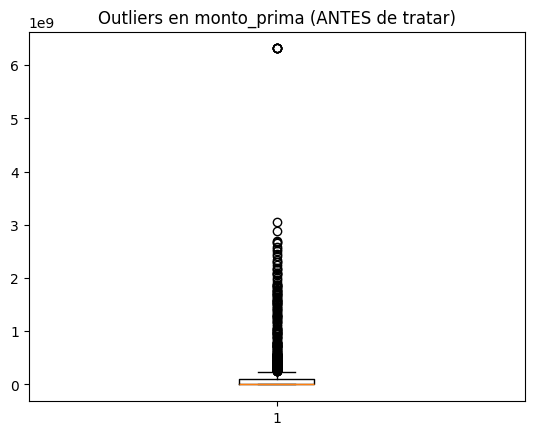

Dimensiones del dataset: (1275, 50)


In [21]:
#8. Visualizar outliers en monto_prima
plt.boxplot(dfLimpieza["monto_prima"])
plt.title("Outliers en monto_prima (ANTES de tratar)")
plt.show()

print(f"Dimensiones del dataset: {dfLimpieza.shape}")

Outliers detectados en monto_prima: 0


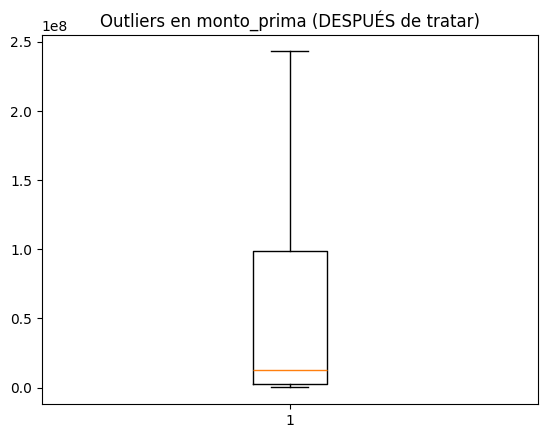

Dimensiones finales del dataset: (1275, 50)


In [23]:
#8.1 Tratamiento de outliers en monto_prima (IQR - capping)
q1, q3 = dfLimpieza['monto_prima'].quantile([0.25, 0.75])
iqr = q3 - q1
lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
n_outliers = ((dfLimpieza['monto_prima'] < lim_inf) | (dfLimpieza['monto_prima'] > lim_sup)).sum()
print(f"Outliers detectados en monto_prima: {n_outliers}")

dfLimpieza['monto_prima'] = dfLimpieza['monto_prima'].clip(lower=lim_inf, upper=lim_sup)

plt.boxplot(dfLimpieza["monto_prima"])
plt.title("Outliers en monto_prima (DESPUÉS de tratar)")
plt.show()

print(f"Dimensiones finales del dataset: {dfLimpieza.shape}")

In [24]:
# 9. Detección de outliers en otras variables clave (sin capping, solo se documentan)
vars_revisar = ['ratio_siniestralidad', 'monto_total_siniestros', 'monto_total_pagado']
vars_revisar = [v for v in vars_revisar if v in dfLimpieza.columns]
print("\nOutliers detectados en otras variables (no tratados, se documentan como limitación):")
for col in vars_revisar:
    q1c, q3c = dfLimpieza[col].quantile([0.25, 0.75])
    iqrc = q3c - q1c
    lim_infc, lim_supc = q1c - 1.5*iqrc, q3c + 1.5*iqrc
    n_out = ((dfLimpieza[col] < lim_infc) | (dfLimpieza[col] > lim_supc)).sum()
    print(f"  {col}: {n_out} outliers")


Outliers detectados en otras variables (no tratados, se documentan como limitación):
  ratio_siniestralidad: 162 outliers
  monto_total_siniestros: 153 outliers
  monto_total_pagado: 188 outliers


#**Validacion de Tipos de Datos**

In [25]:
# 10.Validación y corrección de tipos de datos
cols_codigo_texto = ['codigo_zona_sismica', 'codigo_divipola']
for col in cols_codigo_texto:
    if col in dfLimpieza.columns:
        dfLimpieza[col] = dfLimpieza[col].astype(str)

for col in cols_categoricas_imputar:
    if col in dfLimpieza.columns:
        dfLimpieza[col] = dfLimpieza[col].astype('category')

print(f"Tipos corregidos — códigos a texto: {cols_codigo_texto}")
print(f"Tipos corregidos — categóricas a 'category': {cols_categoricas_imputar}")

Tipos corregidos — códigos a texto: ['codigo_zona_sismica', 'codigo_divipola']
Tipos corregidos — categóricas a 'category': ['tipo_ramo', 'estado_poliza', 'sector_economico', 'tamaño_empresa', 'aseguradora']


In [26]:
# 11. Segunda pasada de duplicados (tras imputación)
n_dup_post = dfLimpieza.duplicated().sum()
dfLimpieza = dfLimpieza.drop_duplicates().reset_index(drop=True)

print(f"\nDimensiones finales del dataset: {dfLimpieza.shape}")
print(f"Nulos restantes: {dfLimpieza.isnull().sum().sum()}")
print(f"Duplicados restantes: {dfLimpieza.duplicated().sum()}")



Dimensiones finales del dataset: (1274, 50)
Nulos restantes: 0
Duplicados restantes: 0


#**Estadisticos Descriptivos profiling**

In [27]:
#12. Estadísticos descriptivos numéricos
desc_num = dfLimpieza.describe().T
desc_num['mediana'] = dfLimpieza.median(numeric_only=True)
desc_num['asimetria'] = dfLimpieza.skew(numeric_only=True)
desc_num['curtosis'] = dfLimpieza.kurt(numeric_only=True)
display(desc_num.round(2))

,count,mean,min,25%,50%,75%,max,std,mediana,asimetria,curtosis
monto_prima,1274.0,66239753.061641,92222.52,2835759.355,13034790.04,99088547.475,242935773.435,92344252.703037,1.303479e+07,1.18,-0.36
porcentaje_comision,1274.0,0.151569,0.0803,0.1197,0.15335,0.1817,0.2199,0.038335,1.500000e-01,-0.09,-1.02
valor_impuesto,1274.0,37464280.93852,17522.28,504693.91,2404055.395,18826824.0225,581643203.51,88831444.574692,2.404055e+06,3.21,10.47
monto_total_venta,1274.0,248176327.452606,109744.8,2934366.31,15485147.195,159232850.885,3642923222.0,565899759.830149,1.548515e+07,3.13,9.91
fecha_venta,1274,2023-12-23 06:27:41.538461696,2022-01-08 00:00:00,2023-04-02 06:00:00,2023-12-22 00:00:00,2024-09-12 18:00:00,2025-12-21 00:00:00,NaN,NaN,NaN,NaN
fecha_inicio_poliza,1274,2023-07-30 07:02:43.893249536,2021-11-29 00:00:00,2022-11-09 12:00:00,2023-07-26 00:00:00,2024-04-09 18:00:00,2025-11-30 00:00:00,NaN,NaN,NaN,NaN
fecha_fin_poliza,1274,2024-08-03 13:19:07.252747264,2022-11-30 00:00:00,2023-11-29 06:00:00,2024-08-03 00:00:00,2025-04-14 12:00:00,2026-12-01 00:00:00,NaN,NaN,NaN,NaN
nivel_riesgo,1274.0,20.819305,0.38,3.9175,8.385,21.45,385.54,34.387517,8.380000e+00,4.08,25.36
nivel_riesgo_sismico,1274.0,2.983516,1.0,2.0,3.0,4.0,5.0,1.437532,3.000000e+00,0.09,-1.32
latitud,1274.0,5.165607,-4.215,3.01525,5.07,7.09,11.544,2.879108,5.070000e+00,0.04,-0.00


In [28]:
#13. Estadísticos descriptivos categóricos
cat_cols = dfLimpieza.select_dtypes(include='object').columns
for col in cat_cols:
    print(f"\n--- {col} ---")
    print(f"Valores únicos: {dfLimpieza[col].nunique()}")
    print(dfLimpieza[col].value_counts().head(10))


--- id_venta ---
Valores únicos: 1274
id_venta
VTA0001410    1
VTA0000001    1
VTA0000002    1
VTA0000005    1
VTA0000006    1
VTA0000007    1
VTA0000008    1
VTA0000010    1
VTA0000011    1
VTA0000012    1
Name: count, dtype: int64

--- id_poliza ---
Valores únicos: 468
id_poliza
POL000505    9
POL000508    7
POL000425    7
POL000292    7
POL000274    7
POL000382    6
POL000370    6
POL000484    6
POL000028    6
POL000300    6
Name: count, dtype: int64

--- codigo_zona_sismica ---
Valores únicos: 87
codigo_zona_sismica
52356    42
25899    34
68001    34
52001    33
85001    32
5088     30
52418    27
15759    27
5615     27
52612    24
Name: count, dtype: int64

--- tipo_sector ---
Valores únicos: 18
tipo_sector
D    115
G    114
O    101
B     82
F     75
I     74
M     74
Q     74
H     72
J     70
Name: count, dtype: int64

--- ciudad ---
Valores únicos: 87
ciudad
Ipiales        42
Zipaquirá      34
Bucaramanga    34
Pasto          33
Yopal          32
Bello          30
La Unión 

#**Transformacion**

In [29]:
# 14. Codificación ordinal y nuevas variables (Feature Engineering)
orden_tamano = {'Microempresa': 1, 'Pequeña': 2, 'Mediana': 3, 'Grande': 4, 'Corporativo': 5}
if 'tamaño_empresa' in dfLimpieza.columns:
    dfLimpieza['tamaño_empresa_num'] = dfLimpieza['tamaño_empresa'].map(orden_tamano)

print("Variable creada: tamaño_empresa_num")


Variable creada: tamaño_empresa_num


In [30]:
# 15. Normalización de formatos categóricos
for col in ['tipo_ramo', 'sector_economico', 'aseguradora']:
    if col in dfLimpieza.columns:
        dfLimpieza[col] = dfLimpieza[col].astype(str).str.strip().str.title()

print("Formatos normalizados en variables categóricas clave")

Formatos normalizados en variables categóricas clave


In [31]:
# 16. Agregación de métricas clave
print("\n" + "="*60)
print("AGREGACIÓN DE MÉTRICAS CLAVE")
print("="*60)

metricas_ramo = dfLimpieza.groupby('tipo_ramo')['monto_prima'].agg(['mean', 'median', 'count']).round(0)
metricas_ramo.columns = ['prima_promedio', 'prima_mediana', 'num_polizas']
print("\nMétricas por Tipo de Ramo:")
display(metricas_ramo.sort_values('prima_promedio', ascending=False))

if 'ratio_siniestralidad' in dfLimpieza.columns:
    metricas_tamano = dfLimpieza.groupby('tamaño_empresa')['ratio_siniestralidad'].mean().round(2)
    print("\nRatio de Siniestralidad Promedio por Tamaño de Empresa:")
    print(metricas_tamano)


AGREGACIÓN DE MÉTRICAS CLAVE

Métricas por Tipo de Ramo:


,prima_promedio,prima_mediana,num_polizas
tipo_ramo,,,
Rc General,89339808.0,58323123.0,52
Multirriesgo,84754013.0,15868619.0,51
Soat,84163270.0,16210085.0,88
Fianza,82818036.0,13395460.0,104
Incendio Y Aliados,74592039.0,13034790.0,93
Transporte,74578069.0,25943389.0,98
Terremoto,66268839.0,17046220.0,53
Automóviles,64008673.0,12440467.0,198
Vida Grupo,62625734.0,10953914.0,90



Ratio de Siniestralidad Promedio por Tamaño de Empresa:
tamaño_empresa
Corporativo      3.77
Grande           6.42
Mediana         12.55
Microempresa    42.91
Pequeña         22.41
Name: ratio_siniestralidad, dtype: float64


/tmp/ipykernel_41902/3571019350.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  metricas_tamano = dfLimpieza.groupby('tamaño_empresa')['ratio_siniestralidad'].mean().round(2)


In [32]:
# 17. Identificación de variables para codificación (se aplica formalmente en el Pipeline de modelado)
cols_a_codificar = ['tipo_ramo', 'tamaño_empresa', 'sector_economico']
cols_a_codificar = [c for c in cols_a_codificar if c in dfLimpieza.columns]
print(f"\nVariables identificadas para codificación (One-Hot Encoding): {cols_a_codificar}")
print("Esta codificación se aplicará formalmente dentro del Pipeline de modelado.")


Variables identificadas para codificación (One-Hot Encoding): ['tipo_ramo', 'tamaño_empresa', 'sector_economico']
Esta codificación se aplicará formalmente dentro del Pipeline de modelado.


#**EDA**

In [33]:
# 18. Configuración de colores corporativos
AZUL, AZUL2, AZUL3 = "#1F4E79", "#2E75B6", "#9DC3E6"
AMARILLO, ROJO, VERDE = "#F4B942", "#C0392B", "#1E8449"
sns.set_theme(style="whitegrid")

/tmp/ipykernel_41902/3692599908.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="tamaño_empresa", y="monto_prima", data=dfLimpieza, order=orden_t, palette="Blues", ax=ax)


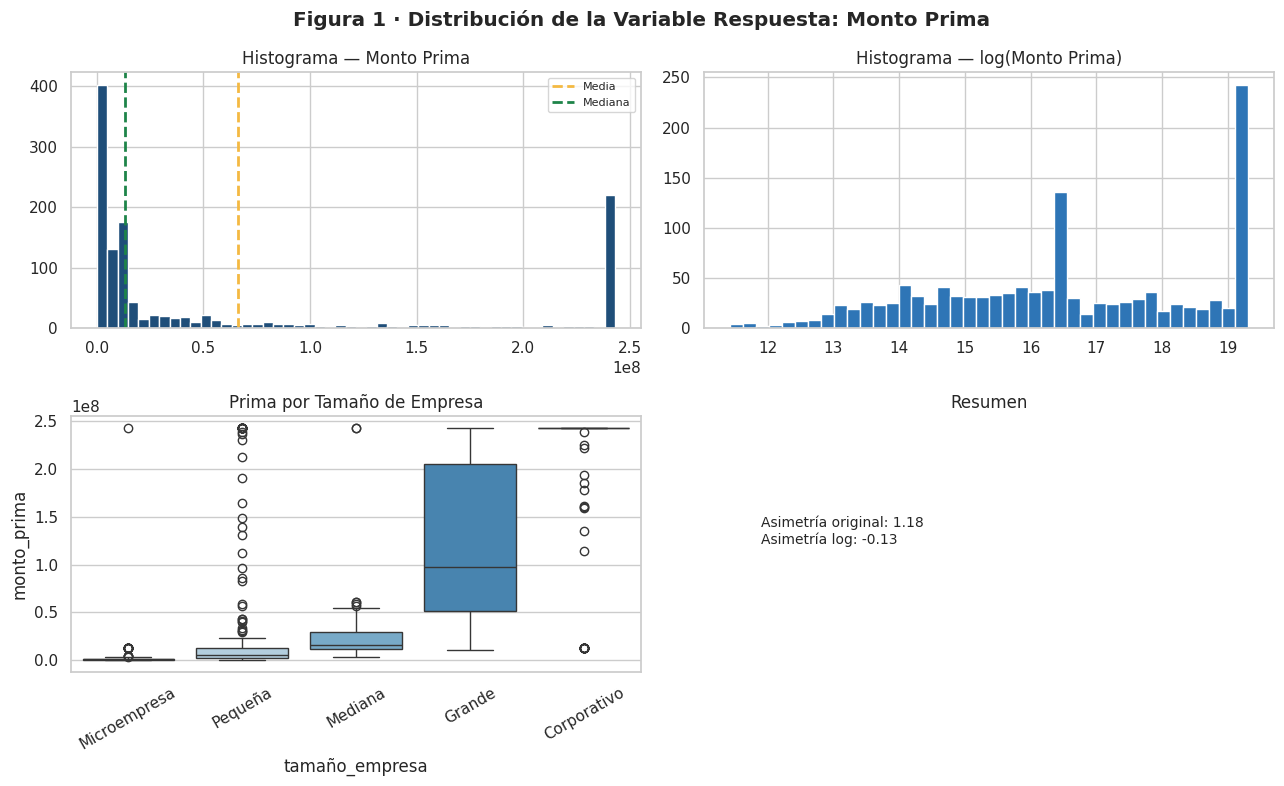

In [34]:
# 19. Figura 1: Distribución de monto_prima
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle("Figura 1 · Distribución de la Variable Respuesta: Monto Prima", fontweight="bold")

ax = axes[0,0]
ax.hist(dfLimpieza["monto_prima"], bins=50, color=AZUL, edgecolor="white")
ax.set_title("Histograma — Monto Prima")
ax.axvline(dfLimpieza["monto_prima"].mean(), color=AMARILLO, lw=2, ls="--", label="Media")
ax.axvline(dfLimpieza["monto_prima"].median(), color=VERDE, lw=2, ls="--", label="Mediana")
ax.legend(fontsize=8)

ax = axes[0,1]
log_p = np.log1p(dfLimpieza["monto_prima"])
ax.hist(log_p, bins=40, color=AZUL2, edgecolor="white")
ax.set_title("Histograma — log(Monto Prima)")

ax = axes[1,0]
orden_t = [t for t in ["Microempresa","Pequeña","Mediana","Grande","Corporativo"] if t in dfLimpieza["tamaño_empresa"].unique()]
sns.boxplot(x="tamaño_empresa", y="monto_prima", data=dfLimpieza, order=orden_t, palette="Blues", ax=ax)
ax.set_title("Prima por Tamaño de Empresa")
ax.tick_params(axis="x", rotation=30)

ax = axes[1,1]
ax.axis("off")
ax.text(0.1, 0.5, f"Asimetría original: {dfLimpieza['monto_prima'].skew():.2f}\nAsimetría log: {log_p.skew():.2f}", fontsize=10)
ax.set_title("Resumen")

plt.tight_layout()
plt.savefig("fig1_distribucion.png", dpi=150)
plt.show()

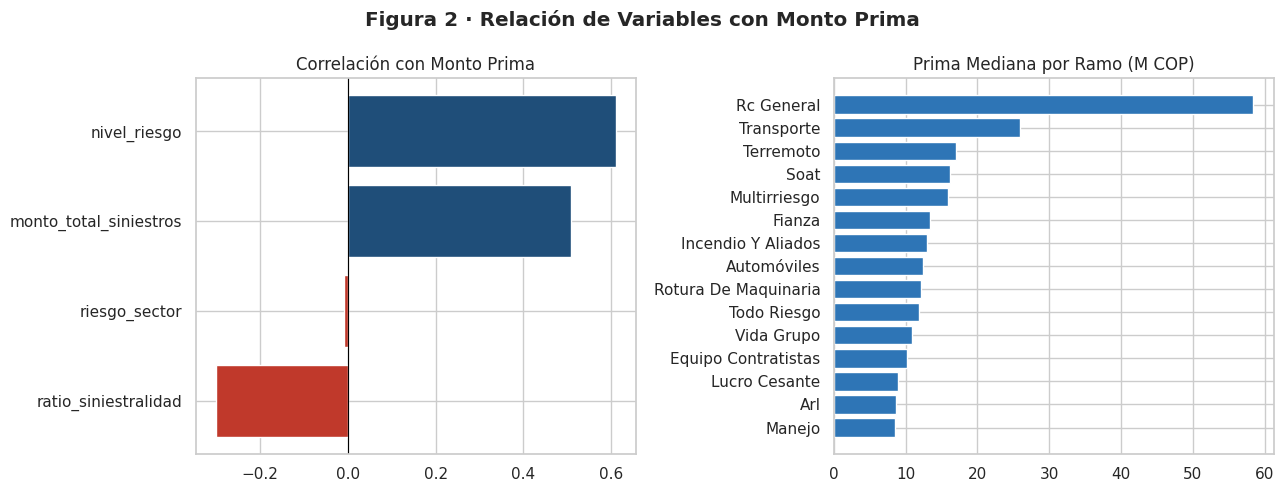

In [35]:
# 20. Figura 2: Correlaciones con monto_prima
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Figura 2 · Relación de Variables con Monto Prima", fontweight="bold")

cols_c = [c for c in ["nivel_riesgo","monto_total_siniestros","riesgo_sector","ratio_siniestralidad"] if c in dfLimpieza.columns]
corr_v = dfLimpieza[cols_c + ["monto_prima"]].corr()["monto_prima"].drop("monto_prima").sort_values()
colores = [ROJO if v < 0 else AZUL for v in corr_v.values]
axes[0].barh(corr_v.index, corr_v.values, color=colores)
axes[0].set_title("Correlación con Monto Prima")
axes[0].axvline(0, color="black", lw=0.8)

ramo_med = dfLimpieza.groupby("tipo_ramo")["monto_prima"].median().sort_values()
axes[1].barh(ramo_med.index, ramo_med.values/1e6, color=AZUL2)
axes[1].set_title("Prima Mediana por Ramo (M COP)")

plt.tight_layout()
plt.savefig("fig2_correlaciones.png", dpi=150)
plt.show()

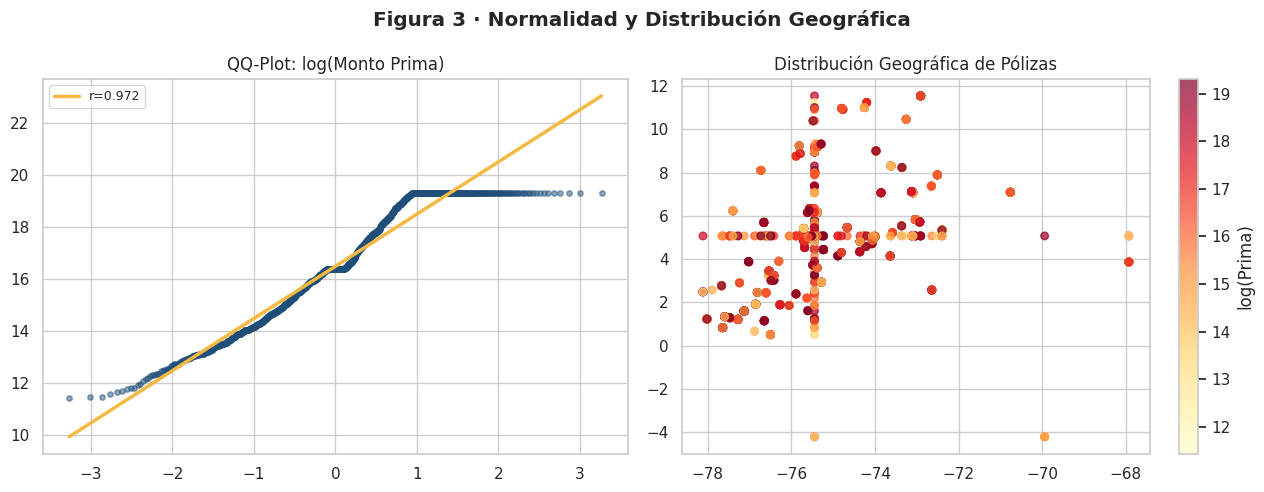

In [36]:
# 21. Figura 3: QQ-Plot y mapa geoespacial
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Figura 3 · Normalidad y Distribución Geográfica", fontweight="bold")

ax = axes[0]
log_p2 = np.log1p(dfLimpieza["monto_prima"])
(osm, osr), (slope, intercept, r_qq) = stats.probplot(log_p2, dist="norm")
ax.scatter(osm, osr, alpha=0.5, s=15, color=AZUL)
xqq = np.array([min(osm), max(osm)])
ax.plot(xqq, slope*xqq+intercept, color=AMARILLO, lw=2.5, label=f"r={r_qq:.3f}")
ax.set_title("QQ-Plot: log(Monto Prima)")
ax.legend(fontsize=9)

ax = axes[1]
if {"latitud","longitud"}.issubset(dfLimpieza.columns):
    sc = ax.scatter(dfLimpieza["longitud"], dfLimpieza["latitud"], c=log_p2, cmap="YlOrRd", alpha=0.7, s=30)
    plt.colorbar(sc, ax=ax, label="log(Prima)")
    ax.set_title("Distribución Geográfica de Pólizas")
else:
    ax.axis("off")

plt.tight_layout()
plt.savefig("fig3_normalidad_geo.png", dpi=150)
plt.show()


6. MATRIZ DE CORRELACIÓN
                         monto_prima  porcentaje_comision  monto_total_venta  \
monto_prima                     1.00                -0.04               0.72   
porcentaje_comision            -0.04                 1.00              -0.00   
monto_total_venta               0.72                -0.00               1.00   
ratio_siniestralidad           -0.16                -0.08              -0.22   
num_sinistros                  -0.02                -0.01               0.00   
monto_total_siniestros          0.48                 0.02               0.67   
antiguedad_meses                0.05                 0.04               0.08   
indice_riesgo_combinado         0.37                 0.02               0.49   

                         ratio_siniestralidad  num_sinistros  \
monto_prima                             -0.16          -0.02   
porcentaje_comision                     -0.08          -0.01   
monto_total_venta                       -0.22           0.00 

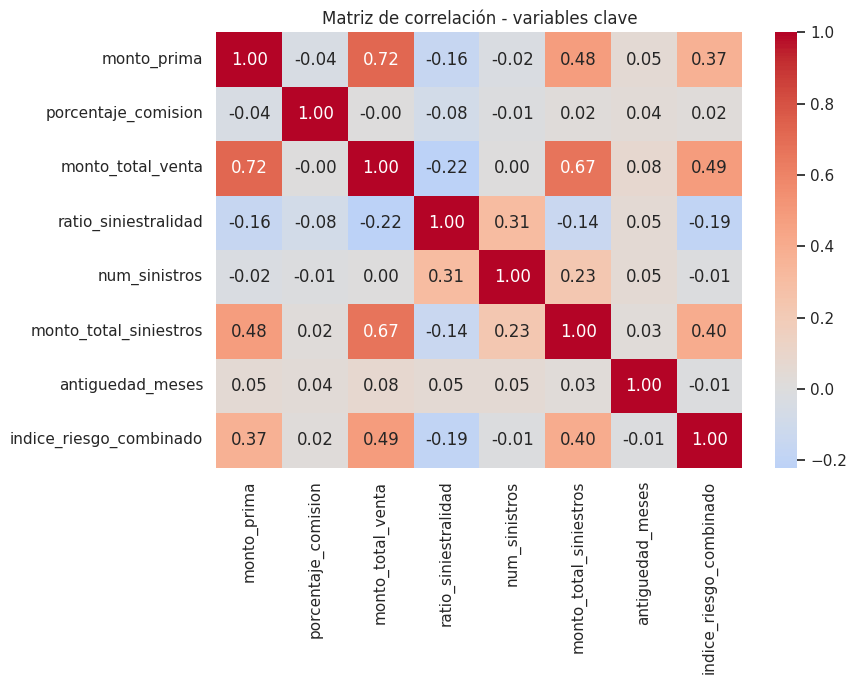

In [37]:
# 23. Correlaciones entre variables numéricas clave
# ------------------------------------------------------------
print("\n" + "="*60)
print("6. MATRIZ DE CORRELACIÓN")
print("="*60)
corr_vars = ['monto_prima', 'porcentaje_comision', 'monto_total_venta',
             'ratio_siniestralidad', 'num_sinistros', 'monto_total_siniestros',
             'antiguedad_meses', 'indice_riesgo_combinado']
corr_vars = [v for v in corr_vars if v in df.columns]
corr = df[corr_vars].corr().round(2)
print(corr)

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Matriz de correlación - variables clave')
plt.tight_layout()
plt.savefig('matriz_correlacion.png', dpi=150)
plt.show()

In [38]:
dfLimpieza.head()

,id_venta,id_poliza,monto_prima,porcentaje_comision,valor_impuesto,monto_total_venta,fecha_venta,tipo_ramo,fecha_inicio_poliza,fecha_fin_poliza,...,prima_diaria,ratio_aprobacion_sinistros,monto_promedio_sinistro,indice_riesgo_combinado,num_tipos_sinistro,es_renovacion,es_cancelada,suma_asegurada_estimada,ramo_alto_riesgo,zona_costera
0,VTA0000001,POL000387,1.977802e+08,0.1995,3.757824e+07,2.353585e+08,2023-12-21,Multirriesgo,2023-07-26,2024-10-11,...,36571.86,0.3333,6.391984e+08,226.525,3,0,0,1977802356,1,1
1,VTA0000002,POL000092,1.717520e+07,0.1629,3.263287e+06,2.043848e+07,2024-07-01,Manejo,2024-01-14,2025-01-14,...,46926.77,0.0000,8.132286e+07,44.876,2,1,0,171751965,0,0
2,VTA0000005,POL000505,4.917586e+05,0.1793,9.343414e+04,5.851928e+05,2023-04-12,Fianza,2022-12-12,2023-12-12,...,1347.28,1.0000,1.874114e+07,0.715,1,0,0,4917586,0,1
3,VTA0000006,POL000252,1.250678e+06,0.1789,2.376287e+05,1.488306e+06,2024-09-21,Todo Riesgo,2024-04-23,2025-04-23,...,3426.51,0.0000,3.543786e+07,7.890,2,0,0,12506775,1,0
4,VTA0000007,POL000217,3.755291e+06,0.0804,2.404055e+06,4.468796e+06,2025-01-27,Automóviles,2023-07-26,2025-01-29,...,10260.36,0.0000,6.340918e+07,11.664,3,0,0,37552910,0,0


In [39]:
print('tamaño_empresa_num' in dfLimpieza.columns)

True


In [ ]:
#14. Guardar dataset limpio todavia no se ha guardado hasta confirmar por favor
ruta_salida = Path("/content/drive/MyDrive/GESTION_ESTRATEGICA_PROYECTO_MARSH/DATA LIMPIA/dataset_polizas_limpio.xlsx")")
dfLimpieza.to_excel(ruta_salida, index=False)
print(f"Dataset limpio guardado en: {ruta_salida}")